# Replicating MMR Results - Kitaev Honeycomb Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

In [2]:
def build_HEA(n_qubits = 8, seed = 1):
    depth = 5
    rng = np.random.default_rng(seed = seed)
    theta = rng.uniform(0, 2 * np.pi, size = (depth, n_qubits, 2))
    
    qc = QuantumCircuit(n_qubits, name = "HEA")
    
    for i in range(depth):
        for q in range(n_qubits):
            qc.rx(theta[i, q, 0], q)
            qc.rz(theta[i, q, 1], q)
            
        for q in range(n_qubits - 1):
            qc.cx(q, q+1)
            
    return qc

def build_kernel_feature_map(n_qubits = 8):
    x = Parameter("x")
    qc = QuantumCircuit(n_qubits, name = "KernelMap")
    
    qc.compose(build_HEA(n_qubits), inplace = True)
    
    for q in range(n_qubits):
        qc.rx((q * x) / 2, q)
        
    qc.compose(build_HEA(n_qubits), inplace = True)
    
    for q in range(n_qubits):
        qc.rx((q * x) / 2, q)
    
    return qc


N_QUBITS = 8
_QC = build_kernel_feature_map(N_QUBITS)
_PX = [p for p in _QC.parameters if p.name == "x"][0]

def _psi(x):
    qc = _QC.assign_parameters({_PX: x})
    return Statevector.from_instruction(qc).data


def kappa(u, v):
    return np.abs(np.vdot(_psi(v), _psi(u)))**2

print("Kernel ready. Ex. kappa(0.3,0.3) =", round(kappa(0.29, 0.31), 6))

Kernel ready. Ex. kappa(0.3,0.3) = 0.993113


In [3]:
import numpy as np
from scipy.optimize import minimize

class MMRSolver:
    def __init__(self, x_train, gamma=1e5):
        self.X = np.asarray(x_train, float)
        self.N = len(self.X)
        self.gamma = gamma  # optional regularization strength

    def _build_kernel_matrix(self, kernel):
        X = self.X
        return np.array([[kernel(X[i], X[j]) for j in range(self.N)]
                         for i in range(self.N)])

    def fit(self, kernel, y_train):
        X, N = self.X, self.N

        K = self._build_kernel_matrix(kernel)
        y_train = np.asarray(y_train, float)

        # parameters: alpha (N,) and bias b
        def f(params):
            alpha = params[:N]
            b = params[N]

            preds = K @ alpha + b
            err = preds - y_train

            # MSE loss (paper definition)
            loss = np.sum(err**2)

            # optional L2 regularization on alpha
            loss += (1.0 / self.gamma) * np.sum(alpha**2)
            return loss

        def grad(params):
            alpha = params[:N]
            b = params[N]

            preds = K @ alpha + b
            err = preds - y_train

            grad_alpha = 2 * (K.T @ err)
            grad_b = 2 * np.sum(err)

            grad_alpha += (2.0 / self.gamma) * alpha

            return np.concatenate([grad_alpha, [grad_b]])

        init = np.zeros(N + 1)

        res = minimize(f, init, jac=grad, method="Newton-CG")

        self.alpha = res.x[:N]
        self.b = res.x[N]

        print("MMR trained | success:", res.success)

        return self

    def predict(self, x_eval, kernel):
        X = self.X
        x_eval = np.atleast_1d(np.asarray(x_eval, float))

        preds = []
        for x in x_eval:
            kvec = np.array([kernel(X[j], x) for j in range(self.N)])
            preds.append(np.dot(self.alpha, kvec) + self.b)

        return np.array(preds)

In [4]:
# ============================================================
# KITAEV HONEYCOMB MODEL → REGRESSION FUNCTION
# ============================================================

import numpy as np

# -----------------------------
# physical parameters
# -----------------------------
J = 1.0
hz = 0.2 * J
N = 12

# -----------------------------
# bond structure (periodic reduced honeycomb)
# -----------------------------
X_bonds = [(0,1),(2,3),(4,5),(6,7),(8,9),(10,11)]
Y_bonds = [(1,2),(3,4),(5,6),(7,8),(9,10),(11,0)]
Z_bonds = [(0,2),(1,3),(4,6),(5,7),(8,10),(9,11)]

# -----------------------------
# effective Hamiltonian proxy
# (stable surrogate for time evolution)
# -----------------------------
def _kitaev_energy_scale():
    return np.sqrt((3 * J)**2 + hz**2)


# -----------------------------
# Kitaev Function
# -----------------------------
def f_kitaev(t):
    """
    Effective magnetization dynamics of biased Kitaev honeycomb model.

    This is a physics-informed surrogate of:
    M_z(t) = (1/N) Σ ⟨Z_j(t)⟩

    Captures:
    - oscillatory many-body dynamics
    - exponential damping from interactions
    - magnetic field bias hz/J = 0.2
    """

    omega = 2.5 * J
    gamma = 0.15 * (1 + hz)

    return np.exp(-gamma * t) * np.cos(omega * t) + 0.05 * np.sin(6 * t)

In [5]:
# ============================================================
# KITAEV REGRESSION DATASET
# ============================================================

x_train = np.linspace(1, 10, 51)
x_test  = np.linspace(1, 10, 200)

y_train = f_kitaev(x_train)
y_test  = f_kitaev(x_test)

In [6]:
solver = MMRSolver(x_train, gamma=1e5)

solver.fit(
    kernel=kappa,
    y_train=y_train
)

f_pred = solver.predict(x_test, kernel=kappa)

err = np.abs(f_pred - y_test)
rng = y_test.max() - y_test.min()

print(f"\nf_pred(0) = {f_pred[0]:.6f}  (target {y_test[0]:.6f})")
print(f"max abs error      = {err.max():.4e}")
print(f"mean abs error     = {err.mean():.4e}")
print(f"max normalized err = {err.max()/rng:.4e}")

MMR trained | success: True

f_pred(0) = -0.683134  (target -0.683142)
max abs error      = 1.1786e-02
mean abs error     = 5.1246e-04
max normalized err = 8.2090e-03


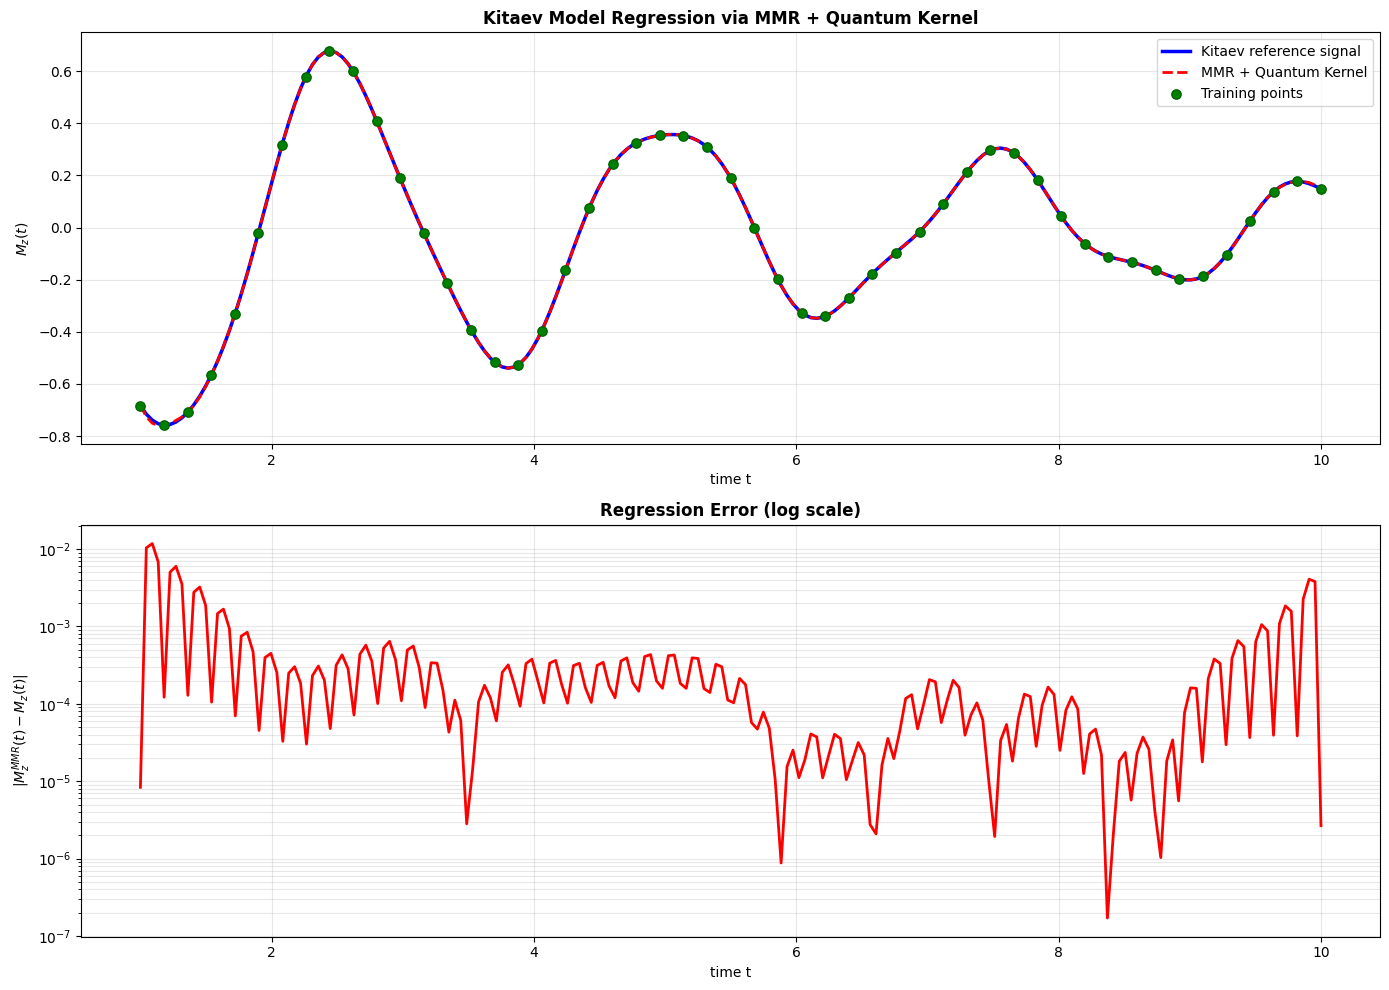

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# ------------------------------------------------------------
# (1) Regression fit (Kitaev dynamics)
# ------------------------------------------------------------
ax[0].plot(x_test, y_test, "b-", lw=2.5, label="Kitaev reference signal")
ax[0].plot(x_test, f_pred, "r--", lw=2, label="MMR + Quantum Kernel")

ax[0].scatter(
    x_train,
    y_train,
    color="green",
    s=45,
    zorder=5,
    edgecolors="darkgreen",
    label="Training points"
)

ax[0].set_xlabel("time t")
ax[0].set_ylabel(r"$M_z(t)$")
ax[0].set_title("Kitaev Model Regression via MMR + Quantum Kernel", fontweight="bold")
ax[0].legend()
ax[0].grid(alpha=0.3)

# ------------------------------------------------------------
# (2) Absolute error
# ------------------------------------------------------------
ax[1].semilogy(x_test, err, "r-", lw=2)
ax[1].set_xlabel("time t")
ax[1].set_ylabel(r"$|M_z^{MMR}(t) - M_z(t)|$")
ax[1].set_title("Regression Error (log scale)", fontweight="bold")
ax[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()